## Introduction

In this module, we introduce the foundational concepts of statistics and their importance in data science. Understanding statistics is crucial for data analysis, enabling informed decision-making based on data insights.

## Dataset Overview

We are using a synthetic dataset representing employees at a company. The dataset includes various aspects such as age, years with the company, salary, job satisfaction, and hours worked per week.



## Importance of Statistics in Data Science

Statistics form the backbone of data science. They allow us to:

- Summarize data to extract meaningful insights.
- Visualize data to understand trends, outliers, and patterns.
- Interpret data to make informed decisions.
- Predict future trends and behaviors.
- Understanding statistics is crucial in various stages of data science projects, from data exploration to modeling and validation.

### Setting Up



In [6]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'employees_dataset.csv'
employees = pd.read_csv(file_path)

# Display the first few rows of the dataframe
employees.head()


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


,EmployeeID,Age,Department,YearsWithCompany,Salary,JobSatisfaction,HoursPerWeek
0,1,62,Development,20,105382,8.0,37
1,2,18,HR,0,65522,4.0,25
2,3,21,HR,1,66039,9.0,34
3,4,21,Development,2,66226,9.0,45
4,5,57,Sales,28,91106,10.0,41


## Descriptive Statistics

Descriptive statistics summarize the central tendency, dispersion, and shape of a dataset's distribution.

### Measures of Central Tendency

In [19]:
# Calculating mean, median, and mode
mean_salary = employees['Salary'].mean()
median_salary = employees['Salary'].median()
mode_salary = employees['Salary'].mode().values

print(f'MEAN: {mean_salary} \nMEDIAN: {median_salary} \nMODE: {mode_salary}')

MEAN: 87087.9 
MEDIAN: 84549.0 
MODE: [76033]


**Application:** Central tendency measures help us understand the typical or central value in our data, essential in salary negotiations, setting budget expectations, and understanding standard company policies.

### Measures of Dispersion

In [20]:
# Calculating standard deviation, variance, and range
std_dev_salary = employees['Salary'].std()
variance_salary = employees['Salary'].var()
range_salary = employees['Salary'].max() - employees['Salary'].min()


**Application:** Measures of dispersion are crucial for risk assessment, understanding inconsistencies in data, quality control, and ensuring fairness in employee remuneration.

### Data Visualization

Visualizations are powerful tools for interpreting complex data.



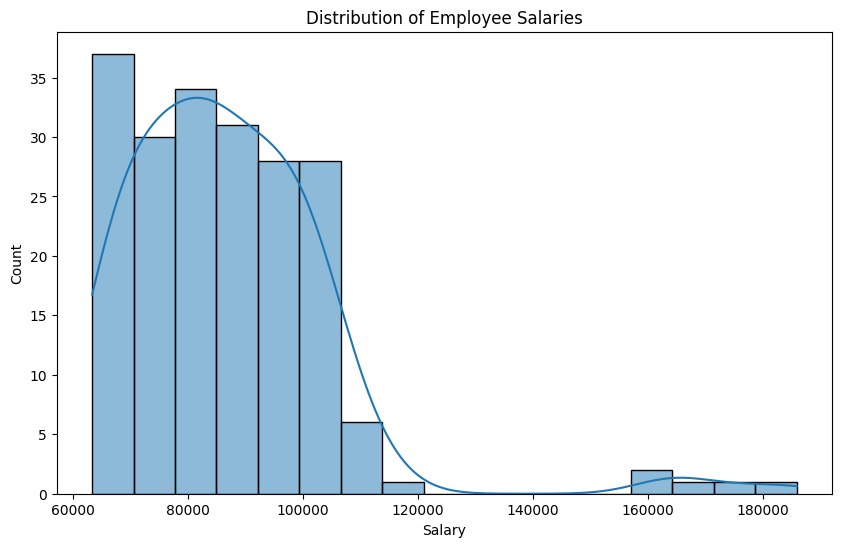

In [21]:
# Histogram of employee salaries
plt.figure(figsize=(10, 6))
sns.histplot(employees['Salary'], kde=True)
plt.title('Distribution of Employee Salaries')
plt.show()


**Application:** Visualizing salary distributions helps HR in benchmarking for competitive compensation, budgeting, and spotting anomalies or disparities.

### Correlation Analysis

Understanding the relationship between different variables.

In [22]:
# Calculate the correlation matrix
correlation_matrix = employees.corr()

# Plot a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix of Employee Attributes')
plt.show()


ValueError: could not convert string to float: 'Development'

### Inferential Statistics

Inferential statistics involve making conclusions about a larger population using data from a sample. It allows us to infer trends about a larger population based on observations made in a representative sample. One common method used in inferential statistics is hypothesis testing.

**Hypothesis Testing**
Hypothesis testing is a statistical method used to test the validity of an assumption (known as a hypothesis) regarding a population parameter. Hypothesis testing involves the following steps:

State the hypotheses: 
- This involves stating the null hypothesis (H0) that there is no effect or difference, and the alternative hypothesis (H1) that there is an effect or difference.

Set the criteria for a decision: 
- Decide on the significance level (commonly set at 0.05), which is the probability of rejecting the null hypothesis when it is true.

Compute the test statistic: 
- Based on the sample data, calculate the test statistic (e.g., t-score, z-score).

Make a decision: 
- Compare the test statistic with the critical value from the statistical tables, and decide whether to reject the null hypothesis.

Let's perform a hypothesis test to determine whether the average salary at our company differs significantly from a known national average (for the purpose of this example, let's assume it is $60,000).

In [ ]:
from scipy import stats

# National average salary
national_avg_salary = 60000

# Conduct a one-sample t-test
t_stat, p_value = stats.ttest_1samp(employees['Salary'], national_avg_salary)

# Print the results
print(f'T-statistic: {t_stat}\nP-value: {p_value}')

# Making a decision
alpha = 0.05
if p_value < alpha:
    print("We reject the null hypothesis.")
else:
    print("We fail to reject the null hypothesis.")


In this scenario, the null hypothesis is that the average salary of our company's employees is the same as the national average. The alternative hypothesis is that the average salary is different from the national average.

**Application:** Hypothesis testing is fundamental in decision-making processes. It's used in quality control, policy effectiveness evaluation, marketing strategies, and understanding impacts of training programs. In our example, it helps the company understand how their remuneration compares with national standards, which is crucial for competitive hiring practices and employee retention strategies.

## Confidence Intervals
Confidence intervals provide a range within which we expect a population parameter (mean, proportion, etc.) to lie with a certain level of confidence. It gives an estimated range of values which is likely to include an unknown population parameter.

In [ ]:
# Calculate the mean salary and the standard error
mean_salary = employees['Salary'].mean()
standard_error = stats.sem(employees['Salary'])

# Calculate the confidence interval
confidence_interval = stats.t.interval(alpha=0.95, df=len(employees['Salary'])-1, loc=mean_salary, scale=standard_error)

print(f'95% confidence interval for the mean salary: {confidence_interval}')


**Application:** Confidence intervals are used in various fields to account for statistical variability when estimating some quantity. They are crucial in decision making, risk management, and planning. For instance, in HR, confidence intervals can be used to set salary ranges for job positions, ensuring they are competitive yet sustainable.

## Regression Analysis

Regression analysis allows us to model, examine, and explore spatial relationships. It helps understand how the typical value of the dependent variable changes when any one of the independent variables is varied.

### Simple Linear Regression
Simple linear regression is used to estimate the relationship between two quantitative variables. You can use it to predict the value of one variable based on the value of another. Let's predict an employee's salary based on their years with the company.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Selecting the predictor and target variables
X = employees['YearsWithCompany'].values.reshape(-1,1)
y = employees['Salary'].values

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating a linear regression model
model = LinearRegression()

# Training the model
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating the model
print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
print(f'R^2 Score: {r2_score(y_test, y_pred)}')

# Plotting
plt.scatter(X_test, y_test, color = 'gray')
plt.plot(X_test, y_pred, color = 'blue', linewidth = 2)
plt.xlabel('Years with the Company')
plt.ylabel('Salary')
plt.title('Salary vs. Years with the Company')
plt.show()


In this example, 'YearsWithCompany' is the independent variable, and 'Salary' is the dependent variable. We are trying to predict salary based on the number of years an employee has been with the company.

**Application:** Simple linear regression can be used in business to evaluate trends and make estimates or forecasts. For example, if a company's sales have increased steadily over the years, employing linear regression to predict sales for the upcoming year could help with budgeting and staffing decisions.

### Multiple Linear Regression
When there are more than two variables, the process is called multiple linear regression. This method is used to model the relationship between a single dependent variable and two or more independent variables.

In [ ]:
# Additional setup for multiple regression
X = employees[['YearsWithCompany', 'Age', 'HoursPerWeek']]  # adding more variables
y = employees['Salary']

# The rest of the process is similar: split the dataset, create the model, train it, make predictions, and evaluate
# ...

# Predictors printing
print('Coefficients: \n', model.coef_)


In this case, we're considering how both the age of employees and their years with the company might influence their salary. The additional predictor, 'Age', has been added to the model.

**Application:** Multiple linear regression can be used in business forecasting, understanding the impact of management decisions on firm performance, evaluating the success of marketing strategies, and more. In human resources, it can help understand how different employee attributes contribute to salary variations, which can inform compensation strategies to make them more equitable.



## Conclusion

In this notebook, we've scratched the surface of how statistics underpin data science projects. From exploring raw data to making informed predictions, statistics provide the methodologies to interpret and make sense of the vast amounts of data in today's digital world.